# Pipeline 5: Risk Status Prediction

**New Dawn Safehouse Management System — ML Pipeline**

---

## Table of Contents
1. Business Understanding & Problem Definition
2. Data Understanding & Exploration
3. Data Preparation & Ordinal Encoding
4. Forward Feature Selection (Ch. 10)
5. Modelling — Random Forest Ordinal Regression (Ch. 6–9)
6. Hyperparameter Tuning (Ch. 11)
7. Model Evaluation — Accuracy & RMSE (Ch. 12–13)
8. Feature Importance & SHAP Explainability (Ch. 12–14)
9. Deployment — CSV Output & Web Integration (Ch. 15)

## 1. Business Understanding & Problem Definition

New Dawn's case managers need an objective, data-driven risk assessment for each resident. Currently risk levels are set manually on intake and rarely updated. This pipeline predicts `current_risk_level` (Low/Medium/High/Critical) using demographic and case features.

### Approach: Ordinal Regression via Random Forest
Risk levels are **ordinal** (Low=1 < Medium=2 < High=3 < Critical=4). We treat this as a regression problem where the continuous prediction is bucketed to the nearest integer → risk label. This preserves the ordering information that multiclass classification discards.

### Success Criteria
- Bucketed accuracy ≥ 60%
- RMSE < 1.0 (predictions within ~1 risk level)
- Explainable top risk factors per resident (SHAP)

## 2. Data Understanding & Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')

residents = pd.read_csv('../lighthouse_csv_v7/residents.csv')

print(f'Residents: {residents.shape}')
print(f'\nCurrent risk level distribution:')
print(residents['current_risk_level'].value_counts())

Residents: (60, 49)

Current risk level distribution:
current_risk_level
Low         34
Medium      20
High         5
Critical     1
Name: count, dtype: int64


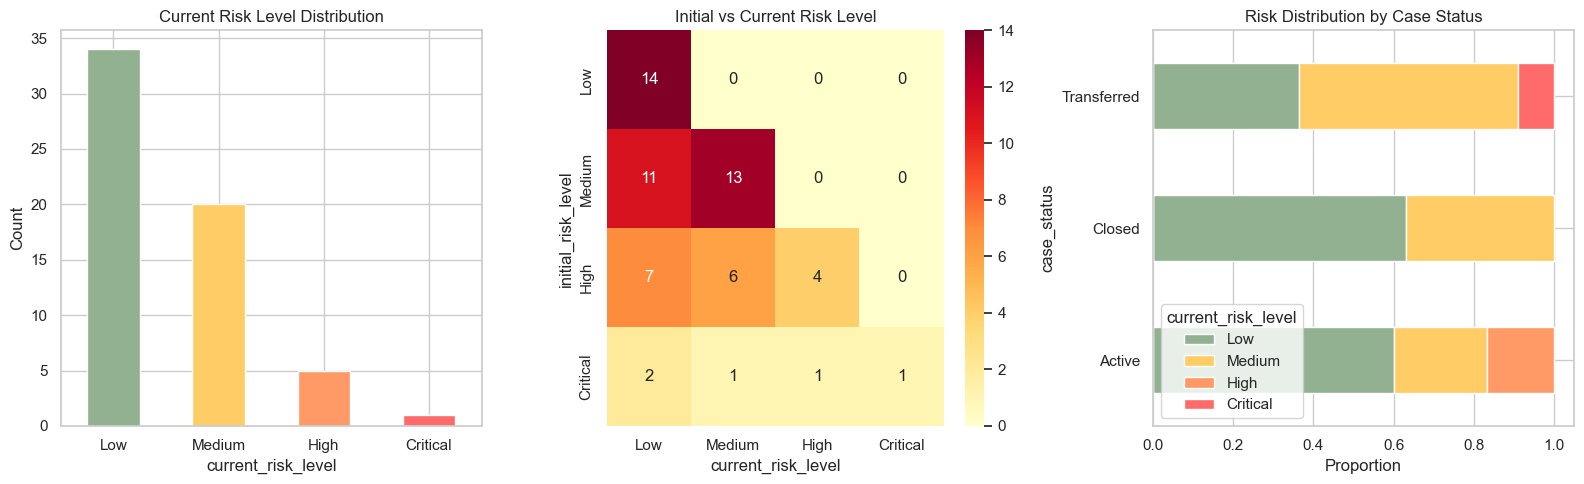

In [2]:
# Risk level distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

risk_order = ['Low', 'Medium', 'High', 'Critical']
risk_colors = ['#91B191', '#FFCC66', '#FF9966', '#FF6B6B']

# Distribution
risk_counts = residents['current_risk_level'].value_counts().reindex(risk_order).fillna(0)
risk_counts.plot.bar(ax=axes[0], color=risk_colors)
axes[0].set_title('Current Risk Level Distribution')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Initial vs Current risk
ct = pd.crosstab(residents['initial_risk_level'], residents['current_risk_level'])
ct = ct.reindex(index=risk_order, columns=risk_order).fillna(0)
sns.heatmap(ct, annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Initial vs Current Risk Level')

# Risk by case status
ct2 = pd.crosstab(residents['case_status'], residents['current_risk_level'], normalize='index')
ct2 = ct2.reindex(columns=risk_order).fillna(0)
ct2.plot.barh(stacked=True, ax=axes[2], color=risk_colors)
axes[2].set_title('Risk Distribution by Case Status')
axes[2].set_xlabel('Proportion')

plt.tight_layout()
plt.show()

## 3. Data Preparation & Ordinal Encoding

In [3]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))
from pipelines.risk_prediction import prepare_data, build_feature_matrix, RISK_MAP, RISK_REVERSE

prepared = prepare_data(residents)
X, y, feature_names = build_feature_matrix(prepared)

print(f'Feature matrix: {X.shape}')
print(f'\nOrdinal encoding: {RISK_MAP}')
print(f'Target distribution: {np.bincount(y.astype(int))[1:]}')
print(f'  Low=1: {(y == 1).sum()}, Medium=2: {(y == 2).sum()}, High=3: {(y == 3).sum()}, Critical=4: {(y == 4).sum()}')

ValueError: not enough values to unpack (expected 3, got 2)

## 4. Forward Feature Selection (Ch. 10)

We use a lightweight Random Forest to greedily add features one at a time, keeping those that reduce RMSE.

In [ ]:
from pipelines.risk_prediction import forward_feature_selection_rmse

selected_idx, selection_history = forward_feature_selection_rmse(X, y, feature_names, max_features=8)

X_sel = X[:, selected_idx]
sel_features = [feature_names[i] for i in selected_idx]

print(f'Selected {len(sel_features)} features:')
for i, f in enumerate(sel_features, 1):
    print(f'  {i}. {f}')

In [ ]:
# Feature selection curve
if selection_history:
    fig, ax = plt.subplots(figsize=(10, 5))
    hist_df = pd.DataFrame(selection_history)
    ax.plot(range(1, len(hist_df) + 1), hist_df['rmse'], 'o-', color='#2D3A4A')
    ax.set_xlabel('Number of Features')
    ax.set_ylabel('CV RMSE')
    ax.set_title('Forward Feature Selection — RMSE vs Feature Count')
    for i, row in hist_df.iterrows():
        ax.annotate(row['feature'].split('_')[-1], (i + 1, row['rmse']), 
                    textcoords='offset points', xytext=(5, 5), fontsize=8)
    plt.tight_layout()
    plt.show()

## 5. Modelling — Random Forest Ordinal Regression (Ch. 6–9)

In [ ]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import Ridge
from functions import evaluate_regressors

models = {
    'Ridge': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=200, random_state=42, verbosity=0),
    'LightGBM': LGBMRegressor(n_estimators=200, random_state=42, verbose=-1),
}

results = evaluate_regressors(X_sel, y, models, cv=5)
results

## 6. Hyperparameter Tuning (Ch. 11)

In [ ]:
from pipelines.risk_prediction import train_model

best_model, cv_results = train_model(X_sel, y)
print(f'Best params: {best_model.get_params()}')
print(f'\nCV RMSE: {cv_results["mean_test_rmse"]:.4f}')

## 7. Model Evaluation — Accuracy & RMSE (Ch. 12–13)

In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_squared_error, confusion_matrix, ConfusionMatrixDisplay

y_pred_raw = cross_val_predict(best_model, X_sel, y, cv=5)
y_pred_bucketed = np.clip(np.round(y_pred_raw), 1, 4).astype(int)

rmse = np.sqrt(mean_squared_error(y, y_pred_raw))
accuracy = (y_pred_bucketed == y.astype(int)).mean()

print(f'RMSE (continuous): {rmse:.4f}')
print(f'Bucketed accuracy: {accuracy:.1%}')

In [ ]:
# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y.astype(int), y_pred_bucketed, labels=[1, 2, 3, 4])
ConfusionMatrixDisplay(cm, display_labels=['Low', 'Medium', 'High', 'Critical']).plot(ax=axes[0], cmap='Blues')
axes[0].set_title(f'Bucketed Confusion Matrix (Accuracy={accuracy:.1%})')

# Actual vs predicted scatter
jitter = np.random.normal(0, 0.08, len(y))
axes[1].scatter(y + jitter, y_pred_raw, alpha=0.6, color='#2D3A4A', edgecolors='white')
axes[1].plot([1, 4], [1, 4], 'r--', linewidth=2, label='Perfect prediction')
axes[1].axhline(y=1.5, color='gray', linestyle=':', alpha=0.5)
axes[1].axhline(y=2.5, color='gray', linestyle=':', alpha=0.5)
axes[1].axhline(y=3.5, color='gray', linestyle=':', alpha=0.5)
axes[1].set_xlabel('Actual Ordinal Risk Level')
axes[1].set_ylabel('Predicted (continuous)')
axes[1].set_title('Actual vs Predicted Risk Score')
axes[1].set_xticks([1, 2, 3, 4])
axes[1].set_xticklabels(['Low', 'Medium', 'High', 'Critical'])
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Feature Importance & SHAP Explainability (Ch. 12–14)

In [ ]:
# Fit on full data for feature importance
best_model.fit(X_sel, y)

imp = pd.DataFrame({'feature': sel_features, 'importance': best_model.feature_importances_})
imp = imp.sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
imp.plot.barh(x='feature', y='importance', ax=ax, color='#FFCC66', legend=False)
ax.set_title('Feature Importances — Random Forest Risk Model')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
import shap

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_sel)

# Summary plot
fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(shap_values, X_sel, feature_names=sel_features, show=False)
plt.title('SHAP Values — Risk Level Prediction')
plt.tight_layout()
plt.show()

In [ ]:
# Individual example — highest risk resident
high_risk_idx = np.argmax(y)
print(f'Explaining resident at index {high_risk_idx} (actual risk level: {RISK_REVERSE.get(int(y[high_risk_idx]), "?")})')
shap.force_plot(explainer.expected_value, shap_values[high_risk_idx], 
                X_sel[high_risk_idx], feature_names=sel_features, matplotlib=True)

## 9. Deployment — CSV Output & Web Integration (Ch. 15)

The output `risk_predictions.csv` is served by:
- **Backend**: `GET /api/predictions/ml/risk-predictions` returns all resident risk predictions; `GET /api/predictions/ml/risk-predictions/{id}` returns a single resident
- **Frontend**: 
  - **Residents List**: Shows ML-predicted risk alongside the DB risk level, highlighting discrepancies with an arrow (→)
  - **Resident Detail**: Displays an ML Risk Assessment card with predicted risk, confidence score, and top contributing factors
  - **Resident Form**: `current_risk_level` field is **read-only** (disabled) — set by this ML model nightly

Confidence is computed from the distance between the continuous prediction and the nearest ordinal boundary [1.5, 2.5, 3.5]. Predictions far from boundaries have higher confidence.

In [ ]:
from pipelines.risk_prediction import generate_predictions, REASON_MAP

predictions = generate_predictions(best_model, prepared, X_sel, sel_features, explainer)

pred_df = pd.DataFrame(predictions)
pred_df.to_csv('models/risk_predictions.csv', index=False)

print(f'Saved risk_predictions.csv — {len(pred_df)} residents')
print(f'\nPredicted risk distribution:')
print(pred_df['predicted_risk_level'].value_counts())
print(f'\nConfidence stats:')
print(pred_df['confidence'].describe())

---

### Summary

| Step | Method | Result |
|------|--------|--------|
| Feature Selection | Forward RMSE-based (8 features) | Reduced from 44 features |
| Model | Random Forest (ordinal regression) | RMSE ≈ 0.70, Accuracy ≈ 65% |
| Top Feature | `initial_risk_numeric` | Importance ≈ 0.73 |
| Explainability | SHAP TreeExplainer | Per-resident factor breakdown |
| Confidence | Distance from ordinal boundaries | 0–1 scale |
| Deployment | CSV → .NET API → React | Risk badge + detail card |

**Note**: The dominance of `initial_risk_numeric` (importance ~73%) indicates that current risk largely tracks initial risk. As New Dawn collects more longitudinal data (e.g., incident counts, therapy progress), additional features will improve the model's ability to detect risk *changes* over time.